In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!pip3 install tslearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 15.0 MB/s eta 0:00:00


In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score

## Load in Data

In [ ]:
# start from the sampled dataframe
all_samples = pd.read_csv('/content/gdrive/MyDrive/Next_Step/400_step_samples_forAll.csv')


In [ ]:
# remove all the unneccesary columns
all_samples = all_samples.drop(columns=['Unnamed: 0',' Latitude', ' SampleTimeFine' , ' Longitude',' Altitude', ' Vel_X', ' Vel_Y', ' Vel_Z'])

In [ ]:
all_samples = all_samples.interpolate(method='linear', limit_direction='forward', axis=0)

In [ ]:
all_samples.head()

,og_df_order,PacketCounter,Acc_X,Acc_Y,Acc_Z,FreeAcc_X,FreeAcc_Y,FreeAcc_Z,Gyr_X,Gyr_Y,...,OriInc_q1,OriInc_q2,OriInc_q3,Roll,Pitch,Yaw,trial_num,sensor_place,participant_num,trial_label
0,879,58903,6.290823,6.507605,1.624105,5.573658,4.208811,-3.831135,0.207661,-2.119974,...,0.001038,-0.010600,0.003082,-31.705407,-82.129192,-28.057853,57,93,1,GR
1,880,58904,5.380435,5.289062,1.745266,4.351387,3.873041,-4.710470,-2.632771,-3.316043,...,-0.013163,-0.016579,0.003866,-45.304301,-83.358984,-15.863963,57,93,1,GR
2,881,58905,8.312956,-0.820190,-4.260586,2.172424,-4.272039,-1.753378,-1.752143,-3.209095,...,-0.008760,-0.016045,0.002583,-61.584464,-84.226341,-0.498369,57,93,1,GR
3,882,58906,7.913580,-0.468833,-1.002991,0.807789,-0.989891,-1.925197,0.390170,-3.249244,...,0.001951,-0.016245,0.001938,-80.416096,-84.629082,18.639106,57,93,1,GR
4,883,58907,10.117513,2.237405,1.086333,2.300206,2.451963,0.048345,-1.030613,-3.044835,...,-0.005153,-0.015224,0.001963,-99.307420,-84.405402,37.023354,57,93,1,GR


In [ ]:
# print(all_samples.isnull().any())

In [ ]:
# making sure all sensors have equal classes
all_samples["sensor_place"].value_counts()

sensor_place
93    684000
8B    684000
9B    684000
B6    684000
95    684000
CC    684000
Name: count, dtype: int64

In [ ]:
# remove the calibration data points and the banked R/L to evaluate model performance
# without these variables because in our data collection they wont be included
all_samples = all_samples.drop(all_samples[all_samples["trial_label"] == 'calibration'].index)


In [ ]:
# making sure all surface types have equal classes
all_samples["trial_label"].value_counts()

trial_label
GR      432000
BNKR    432000
BNKL    432000
SLPD    432000
SLPU    432000
STD     432000
STU     432000
CS      432000
FE      432000
Name: count, dtype: int64

In [ ]:
# seperating inputs by the sensor placement
all_samples_CC = all_samples.loc[all_samples['sensor_place'] == "CC"]
all_samples_95 = all_samples.loc[all_samples['sensor_place'] == "95"]
all_samples_93 = all_samples.loc[all_samples['sensor_place'] == "93"]
all_samples_8B = all_samples.loc[all_samples['sensor_place'] == "8B"]
all_samples_9B = all_samples.loc[all_samples['sensor_place'] == "9B"]
all_samples_B6 = all_samples.loc[all_samples['sensor_place'] == "B6"]

In [ ]:
# list of all of the separated dfs
sensor_dfs = [all_samples_CC, all_samples_95, all_samples_93, all_samples_8B, all_samples_9B, all_samples_B6]

In [ ]:
reshaped_metrics_list = []
reshaped_non_metrics_list = []

In [ ]:
for df in sensor_dfs:

  df = df.sort_values(by=['participant_num', 'trial_num', 'og_df_order'])
  metrics = pd.DataFrame(df, columns=[' Acc_X', ' Acc_Y',' Acc_Z', ' FreeAcc_X', ' FreeAcc_Y', ' FreeAcc_Z', ' Gyr_X', ' Gyr_Y',
                                                          ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', ' VelInc_X', ' VelInc_Y',
                                                          ' VelInc_Z'])
  # dataframe of the non measurements
  non_metrics = df[['participant_num', 'trial_num', 'trial_label']].copy()
  # reducing the trial label column down to just 1 label per sequence
  drop_doop = non_metrics.drop_duplicates()
  # reshaping numpy array to the correct format (number of sequences, sequence length, number of features)
  numpy_metrics = metrics.to_numpy()
  reshape_metrics = np.reshape(numpy_metrics, (1620, 400, 15))
  reshaped_metrics_list.append(reshape_metrics)

  # one hot encode the surface labels (outcome labels)
  label_encoder = LabelEncoder()
  integer_encoded_labels = label_encoder.fit_transform(drop_doop['trial_label'])
  one_hot_encoded_labels = to_categorical(integer_encoded_labels)
  numpy_result = np.array(one_hot_encoded_labels)
  reshape_non_metrics = np.reshape(numpy_result, (1620, 9))
  reshaped_non_metrics_list.append(reshape_non_metrics)


## Setting up X and Y train/test

In [ ]:
# establish X and Y variables
X_CC, X_95, X_93, X_8B, X_9B, X_B6 = reshaped_metrics_list[0], reshaped_metrics_list[1], reshaped_metrics_list[2], reshaped_metrics_list[3], reshaped_metrics_list[4], reshaped_metrics_list[5]
Y_CC, Y_95, Y_93, Y_8B, Y_9B, Y_B6 = reshaped_non_metrics_list[0], reshaped_non_metrics_list[1], reshaped_non_metrics_list[2], reshaped_non_metrics_list[3], reshaped_non_metrics_list[4], reshaped_non_metrics_list[5]

In [ ]:
# split in to training and testing data
X_CC_train, X_CC_test, Y_CC_train, Y_CC_test = train_test_split(X_CC, Y_CC, test_size=0.1)
X_95_train, X_95_test, Y_95_train, Y_95_test = train_test_split(X_95, Y_95, test_size=0.1)
X_93_train, X_93_test, Y_93_train, Y_93_test = train_test_split(X_93, Y_93, test_size=0.1)
X_8B_train, X_8B_test, Y_8B_train, Y_8B_test = train_test_split(X_8B, Y_8B, test_size=0.1)
X_9B_train, X_9B_test, Y_9B_train, Y_9B_test = train_test_split(X_9B, Y_9B, test_size=0.1)
X_B6_train, X_B6_test, Y_B6_train, Y_B6_test = train_test_split(X_B6, Y_B6, test_size=0.1)

In [ ]:
# check shapes
X_CC_train.shape, X_CC_test.shape, Y_CC_train.shape, Y_CC_test.shape

((1458, 400, 15), (162, 400, 15), (1458, 9), (162, 9))

In [ ]:
# lists of the x, y train and test sets by sensors
x_trains = [X_CC_train, X_95_train, X_93_train, X_8B_train, X_9B_train, X_B6_train]
x_tests = [X_CC_test, X_95_test, X_93_test, X_8B_test, X_9B_test, X_B6_test]
y_trains = [Y_CC_train, Y_95_train, Y_93_train, Y_8B_train, Y_9B_train, Y_B6_train]
y_tests = [Y_CC_test, Y_95_test, Y_93_test, Y_8B_test, Y_9B_test, Y_B6_test]

In [ ]:
# function for normalizing the data
def preprocess_data(raw_data):
    # Assuming raw_data has shape (batch_size, sequence_length, num_features)
    # Adjust dimensions based on your actual data
    og_data_shape = raw_data.shape
    reshaped_data = raw_data.reshape((og_data_shape[0], og_data_shape[1] * og_data_shape[2]))
    # Normalize the data
    normalized_data = TimeSeriesScalerMinMax().fit_transform(reshaped_data)

    # Reshape back to the original shape
    preprocessed_data = normalized_data.reshape((og_data_shape[0], og_data_shape[1], og_data_shape[2]))
    return preprocessed_data

In [ ]:
Y_trains = [Y_CC_train, Y_95_train, Y_93_train, Y_8B_train, Y_9B_train, Y_B6_train]
Y_tests = [Y_CC_test, Y_95_test, Y_93_test, Y_8B_test, Y_9B_test, Y_B6_test]
Y = [Y_trains, Y_tests]

In [ ]:
# make sure y variables are in np arrays
for i in Y:
  for t in i:
    t = np.array(t)

In [ ]:
# create variables that establish information that will be needed later
n_obs, n_timesteps, n_features, n_classes = x_trains[0].shape[0], x_tests[0].shape[1], x_tests[0].shape[2], Y_CC_train.shape[1]

In [ ]:
# check variables
n_obs, n_timesteps, n_features, n_classes

(1458, 400, 15, 9)

In [26]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense, Bidirectional, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

num_samples = n_obs
sequence_length = n_timesteps
feature_dim = n_features
num_classes = n_classes

# Initialize KFold with desired number of folds
kfold = KFold(n_splits=10, shuffle=True)

# Initialize lists to store evaluation metrics
accuracies = []
conf_matrices = []

# Perform k-fold cross-validation
for train_index, valid_index in kfold.split(X_CC_train):
    x_trains = []
    x_valids = []
    for i, X_train in enumerate([X_CC_train, X_95_train, X_93_train, X_8B_train, X_9B_train, X_B6_train]):
        x_trains.append(X_train[train_index])
        x_valids.append(X_train[valid_index])

    y_train, y_valid = Y_CC_train[train_index], Y_CC_train[valid_index]

    # Clear the session for TensorFlow
    tf.keras.backend.clear_session()

    # Define input shapes for each input
    input_shapes = [(sequence_length, feature_dim) for _ in range(6)]

    # Define the model
    input_layers = [Input(shape=shape) for shape in input_shapes]
    cnn_outs = [Conv1D(filters=128, kernel_size=3, activation='relu')(input_layer) for input_layer in input_layers]
    cnn_outs = [MaxPooling1D(pool_size=2)(cnn_out) for cnn_out in cnn_outs]
    cnn_outs = [Dropout(0.2)(cnn_out) for cnn_out in cnn_outs]
    cnn_outs = [BatchNormalization()(cnn_out) for cnn_out in cnn_outs]
    lstm_outs = [Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out) for cnn_out in cnn_outs]
    attentions = [Attention()([lstm_out, lstm_out]) for lstm_out in lstm_outs]
    merged = [Concatenate(axis=-1)([lstm_out, attention]) for lstm_out, attention in zip(lstm_outs, attentions)]
    mlp_outs = [Flatten()(merge) for merge in merged]
    mlp_outs = [Dense(units=128, activation='relu')(mlp_out) for mlp_out in mlp_outs]
    mlp_outs = [Dense(units=64, activation='relu')(mlp_out) for mlp_out in mlp_outs]
    merged_output = Concatenate()(mlp_outs)
    output_layer = Dense(units=num_classes, activation='softmax')(merged_output)
    model = tf.keras.models.Model(inputs=input_layers, outputs=output_layer)

    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Early stopping callback
    callback = EarlyStopping(monitor='loss', patience=10)

    # Train the model
    history = model.fit(x=x_trains, y=y_train, validation_data=(x_valids, y_valid), epochs=200, batch_size=128, callbacks=[callback])

    # Make predictions on the validation data
    fold_predictions = model.predict(x_valids)
    fold_predictions_labels = np.argmax(fold_predictions, axis=1)
    y_valid_labels = np.argmax(y_valid, axis=1)

    # Compute accuracy for this fold
    accuracy = accuracy_score(y_valid_labels, fold_predictions_labels)
    accuracies.append(accuracy)

    # Compute confusion matrix for this fold
    conf_matrix = confusion_matrix(y_valid_labels, fold_predictions_labels)
    conf_matrices.append(conf_matrix)

# Calculate average accuracy across all folds
avg_accuracy = sum(accuracies) / len(accuracies)
print("Average Validation Accuracy:", avg_accuracy)

# Print confusion matrices for each fold
for i, conf_matrix in enumerate(conf_matrices):
    print("Confusion Matrix - Fold", i+1, ":\n", conf_matrix)

# Evaluate the model on the test set
x_tests = [X_CC_test, X_95_test, X_93_test, X_8B_test, X_9B_test, X_B6_test]
test_loss, test_accuracy = model.evaluate(x=x_tests, y=Y_CC_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Epoch 1/200
11/11 [==============================] - 52s 2s/step - loss: 2.1204 - accuracy: 0.1951 - val_loss: 2.8741 - val_accuracy: 0.1233
Epoch 2/200
11/11 [==============================] - 20s 2s/step - loss: 1.4103 - accuracy: 0.5892 - val_loss: 2.8338 - val_accuracy: 0.1233
Epoch 3/200
11/11 [==============================] - 21s 2s/step - loss: 0.9846 - accuracy: 0.7332 - val_loss: 2.5989 - val_accuracy: 0.1507
Epoch 4/200
11/11 [==============================] - 21s 2s/step - loss: 0.6747 - accuracy: 0.8521 - val_loss: 2.3992 - val_accuracy: 0.2397
Epoch 5/200
11/11 [==============================] - 20s 2s/step - loss: 0.4681 - accuracy: 0.9131 - val_loss: 2.2394 - val_accuracy: 0.2945
Epoch 6/200
11/11 [==============================] - 21s 2s/step - loss: 0.3072 - accuracy: 0.9726 - val_loss: 2.1865 - val_accuracy: 0.2740
Epoch 7/200
11/11 [==============================] - 20s 2s/step - loss: 0.2101 - accuracy: 0.9893 - val_loss: 2.0516 - val_accuracy: 0.3356
Epoch 8/200
1

## Train Model

In [ ]:
# # Generate some random data for demonstration purposes
# num_samples = n_obs
# sequence_length = n_timesteps
# feature_dim = n_features
# num_classes = n_classes

# input_data = np.array(fft_x_trains)
# labels = np.array(Y_trains)

# input_dict = {'input_1': input_data[0],
#               'input_2': input_data[1],
#               'input_3': input_data[2],
#               'input_4': input_data[3],
#               'input_5': input_data[4],
#               'input_6': input_data[5]}

# # Compile the model (if not compiled already)
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
# callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=8)
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# # Train the model
# history = model.fit(x=input_dict, y=Y_CC_train, epochs=200, batch_size=64, validation_split=0.2, callbacks=[callback])


## Model performance graphs

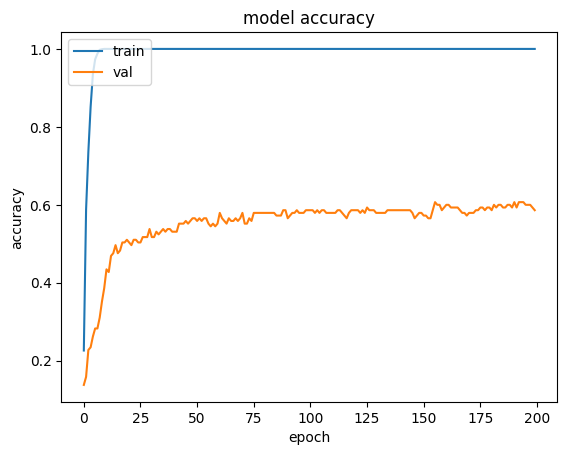

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

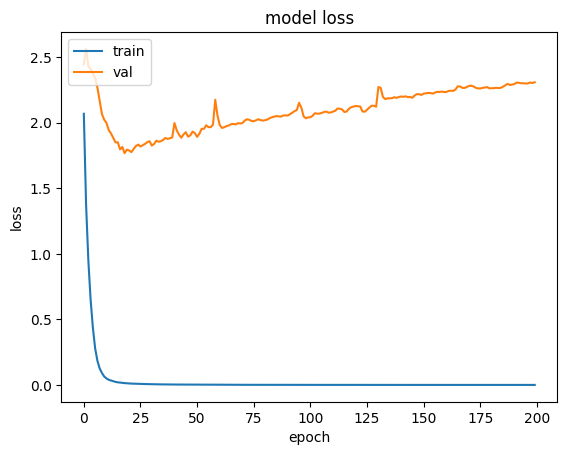

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [29]:
# # Get the weights of the individual branch models
# branch_weights = []

# for branch_model in branch_models:
#     branch_weights.append(branch_model.get_weights())

# # Print the weights for each branch
# for i, branch_weight in enumerate(branch_weights):
#     print(f"Weights for Branch {i + 1}:", branch_weight)

In [30]:
# Get the weights of the main model
main_model_weights = model.get_weights()

# # Print the weights for each layer
# for layer_weights in main_model_weights:
#     print(layer_weights)

In [31]:
# mse_values = {}
# # Compare weights of corresponding layers in each branch
# for i, branch_model in enumerate(branch_models):
#     branch_weights = branch_model.get_weights()

#     for layer_idx in range(len(branch_weights)):
#         # Ensure that the shapes are compatible for element-wise operations
#         if layer_idx == 0 or layer_idx == 1 or layer_idx == 3 or layer_idx == 5:  # Choose layers to compare
#             if branch_weights[layer_idx].shape == main_model_weights[layer_idx].shape:
#                 mse = np.mean(np.square(np.subtract(branch_weights[layer_idx], main_model_weights[layer_idx])))
#                 print(f"Branch {i + 1}, Layer {layer_idx + 1} - Mean Squared Error: {mse}")

#                 # Use a tuple as a key in the mse_values dictionary
#                 key = (i+1, layer_idx+1)

#                 # Initialize the list for the key if it doesn't exist
#                 if key not in mse_values:
#                     mse_values[key] = []

#                 mse_values[key].append(mse)
#             else:
#                 print(f"Shapes mismatch for Branch {i + 1}, Layer {layer_idx + 1}")

# # Set the size of the plot
# plt.figure(figsize=(20, 10))  # Adjust the values as needed

# # Plot mean squared differences for each layer and branch
# for key, values in mse_values.items():
#     plt.bar(str(key), np.mean(values), label=str(key))

# plt.xlabel('Layer')
# plt.ylabel('Mean Squared Error')
# plt.title('Mean Squared Error for Each Layer and Branch')
# plt.xticks(rotation=45, ha='right')
# plt.legend()
# plt.show()


In [32]:
# # Plot mean squared differences for each layer and branch as a line plot
# grouped_values = {}
# for key, values in mse_values.items():
#     if len(values) > 0:  # Check if the list is not empty
#         # Use only unique values from 1 to 6 as labels
#         label = min(max(key[0], 1), 6)
#         if label not in grouped_values:
#             grouped_values[label] = {'x': [], 'y': []}
#         grouped_values[label]['x'].append(key[1])  # Append each x-value individually
#         grouped_values[label]['y'].extend(values)

# # Set the size of the plot
# plt.figure(figsize=(20, 10))  # Adjust the values as needed

# # Plot the grouped lines with x-axis as the second value of the tuple
# for group_label, group_data in grouped_values.items():
#     plt.plot(group_data['x'], group_data['y'], label=f'Branch {group_label}', marker='o')

# plt.xlabel('Layer')
# plt.ylabel('Mean Squared Error')
# plt.title('Mean Squared Error for Each Layer and Branch')
# plt.xticks(rotation=45, ha='right')
# plt.legend()
# plt.show()


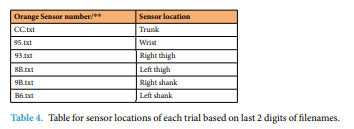

## Confusion Matrix

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# input_data = np.array(x_trains)

print("Evaluate on test data")
results = model.evaluate(x_tests, Y_CC_test, batch_size=128)
print("test loss, test acc:", results)


# # Generate predictions (probabilities -- the output of the last layer)
# # on new data using `predict`
# print("Generate predictions for 3 samples")
# predictions = model.predict(fft_x_tests, verbose=0)[:100]
# print("predictions shape:", predictions.shape)


#Predict
y_prediction = model.predict(x_tests)

#Create confusion matrix and normalizes it over predicted (columns)
y_prediction = np.argmax(y_prediction, axis=1)
print(y_prediction)
Y_9B_test_proc = np.argmax(Y_9B_test, axis=1)
print(Y_9B_test_proc)
result = confusion_matrix(Y_9B_test_proc, y_prediction , normalize='pred')

# Compute F1 score
f1 = f1_score(Y_9B_test_proc, y_prediction, average='weighted')
print("F1 score:", f1)

Evaluate on test data
2/2 [==============================] - 1s 179ms/step - loss: 2.4626 - accuracy: 0.6235
test loss, test acc: [2.4625911712646484, 0.6234567761421204]
6/6 [==============================] - 1s 120ms/step
[7 5 5 4 1 1 7 2 4 1 4 4 6 0 1 5 4 4 8 1 7 3 0 7 1 2 7 8 2 5 1 1 4 5 5 7 1
 3 1 6 3 1 8 0 8 7 1 7 3 5 0 4 6 1 0 2 3 0 4 2 7 0 8 4 8 5 7 5 4 5 0 1 1 8
 5 8 3 6 8 4 0 0 2 8 1 0 3 0 3 0 0 3 0 3 3 3 0 3 5 8 0 8 8 1 5 3 6 0 8 7 5
 1 6 5 1 1 4 4 6 1 3 1 7 8 2 2 6 7 0 6 7 7 5 5 8 6 0 7 5 8 6 1 8 5 8 8 4 6
 8 5 3 0 3 1 4 5 5 5 1 8 4 1]
[3 5 2 2 2 1 8 0 8 3 2 0 4 6 4 6 7 7 7 2 6 4 5 8 4 2 8 1 8 4 8 7 3 8 7 0 8
 5 6 0 4 6 0 2 6 1 0 1 2 3 0 5 8 3 4 1 1 6 0 6 2 5 6 2 5 4 4 5 2 7 3 4 6 7
 3 0 8 6 6 7 5 4 3 0 6 8 8 7 0 4 8 8 3 3 4 5 7 7 1 4 2 3 1 2 4 5 8 4 2 1 6
 6 6 6 3 3 2 6 3 6 6 3 7 3 3 1 4 4 7 6 7 0 2 5 7 6 5 0 4 4 2 0 1 4 7 8 0 8
 7 4 4 0 0 0 6 1 4 8 1 8 0 5]
F1 score: 0.10451486082922398


In [34]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics


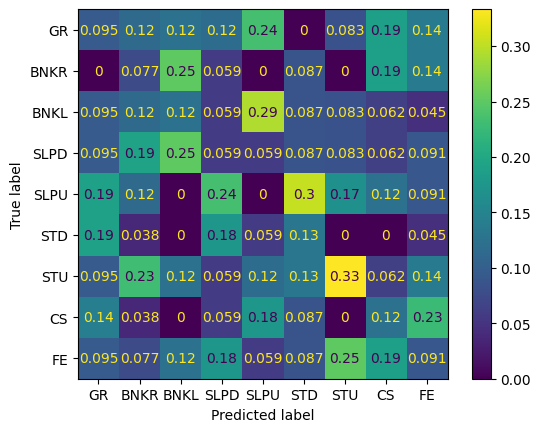

In [35]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['GR', 'BNKR', 'BNKL', 'SLPD', 'SLPU', 'STD', 'STU', 'CS', 'FE'])

cm_display.plot()
plt.show()

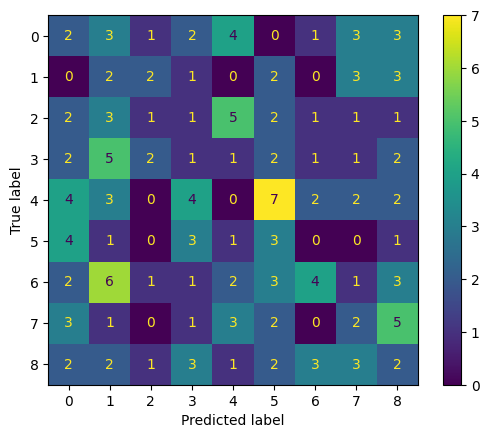

In [38]:
ConfusionMatrixDisplay.from_predictions(Y_9B_test_proc, y_prediction)

In [ ]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

In [ ]:
# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE